# AI & ML Lab - Experiment 1

## Experiment: Data Preprocessing Using Python

**Name:** Saniya Jose

**Roll No:** 62

**Class:** R5B

**Dataset:** Student Performance Dataset

**Dataset Source:** Kaggle

**Dataset Link:** https://www.kaggle.com/datasets/haseebindata/student-performance-predictions

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from scipy.stats import zscore

## Step 1: Upload and Load the Dataset

The dataset is uploaded manually into Google Colab using the **Files** panel. After uploading, it is loaded into a Pandas DataFrame for preprocessing.

In [3]:
df = pd.read_csv("student_performance_updated_1000-selected-columns.csv")

df.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1


## Step 2: Display Basic Information

The structure of the dataset is examined by displaying the number of rows, columns, data types, descriptive statistics, and missing values.

In [4]:
print("Shape:", df.shape)

print("\nData Types")
print(df.dtypes)

print("\nDataset Information")
df.info()

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())

Shape: (1000, 10)

Data Types
StudentID                    float64
Name                          object
Gender                        object
AttendanceRate               float64
StudyHoursPerWeek            float64
PreviousGrade                float64
ExtracurricularActivities    float64
ParentalSupport               object
FinalGrade                   float64
Study Hours                  float64
dtype: object

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    float64
 1   Name                       966 non-null    object 
 2   Gender                     952 non-null    object 
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   Extrac

## Step 3: Display First, Last, and Random Records

Displaying different records helps in understanding the contents of the dataset.

In [5]:
print("First Five Rows")
display(df.head())

print("Last Five Rows")
display(df.tail())

print("Random Five Rows")
display(df.sample(5))

First Five Rows


,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1


Last Five Rows


,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours
995,NaN,Kenneth Murray,Male,85.0,20.0,NaN,1.0,High,72.0,0.8
996,4497.0,Amy Stout,Female,91.0,NaN,86.0,0.0,High,90.0,3.9
997,1886.0,NaN,Male,85.0,8.0,82.0,2.0,Low,68.0,0.4
998,7636.0,Joseph Sherman,Male,88.0,17.0,60.0,2.0,High,85.0,0.9
999,8021.0,Maria Walls,Female,88.0,10.0,90.0,1.0,Medium,NaN,2.4


Random Five Rows


,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours
588,3744.0,Mrs. Amy Carney MD,Male,91.0,18.0,86.0,2.0,High,78.0,2.9
566,1831.0,NaN,Male,85.0,NaN,78.0,2.0,Medium,80.0,0.4
688,1612.0,Belinda Kim,Female,70.0,22.0,70.0,0.0,Medium,80.0,3.5
669,4365.0,Ashley Jordan,Male,78.0,30.0,78.0,2.0,High,85.0,4.7
682,1517.0,Andrew Dudley,Female,90.0,8.0,77.0,1.0,Medium,78.0,2.3


## Step 4: Detect and Handle Missing Values

Missing values are detected using the `isnull()` function. Numerical columns are filled using the median value, while categorical columns are filled using the mode. This ensures that no missing values remain before further preprocessing.

In [16]:
# Check missing values
print("Missing Values Before Handling")
print(df.isnull().sum())

Missing Values Before Handling
StudentID                    0
Name                         0
Gender                       0
AttendanceRate               0
StudyHoursPerWeek            0
PreviousGrade                0
ExtracurricularActivities    0
ParentalSupport              0
FinalGrade                   0
Study Hours                  0
dtype: int64


In [17]:
# Handle StudentID
df["StudentID"] = df["StudentID"].fillna("Unknown_ID")

# Handle Name
df["Name"] = df["Name"].fillna("Unknown")

In [18]:
# Fill remaining categorical columns with mode
cat_cols = ["Gender", "ExtracurricularActivities", "ParentalSupport"]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [19]:
# Fill numerical columns with mode
num_cols = df.select_dtypes(include="number").columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [20]:
print("Missing Values After Handling")
print(df.isnull().sum())

Missing Values After Handling
StudentID                    0
Name                         0
Gender                       0
AttendanceRate               0
StudyHoursPerWeek            0
PreviousGrade                0
ExtracurricularActivities    0
ParentalSupport              0
FinalGrade                   0
Study Hours                  0
dtype: int64


## Step 5: Detect and Remove Duplicate Records

Duplicate records increase redundancy and may affect data analysis. The duplicate rows are identified using the `duplicated()` function and removed using `drop_duplicates()`.

In [21]:
duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 0


In [22]:
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates")
print(df.shape)

Dataset Shape After Removing Duplicates
(1000, 10)


## Step 6: Detect Outliers Using IQR Method

Outliers are detected using the Interquartile Range (IQR) method. A box plot is also generated to visualize the presence of outliers in numerical columns.

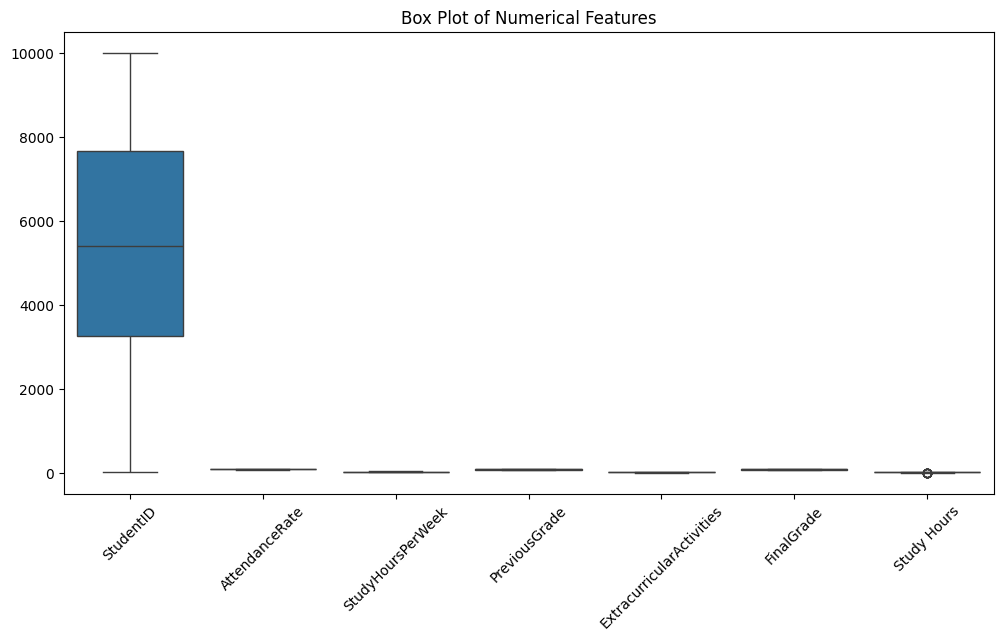

In [23]:
# Display boxplots for all numerical columns
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=45)
plt.title("Box Plot of Numerical Features")
plt.show()

In [24]:
# Detect outliers using IQR for FinalGrade

Q1 = df["FinalGrade"].quantile(0.25)
Q3 = df["FinalGrade"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["FinalGrade"] < lower) | (df["FinalGrade"] > upper)]

print("Number of Outliers :", len(outliers))
display(outliers)

Number of Outliers : 0


,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours


### Observation

Using the IQR method, no outliers were detected in the **FinalGrade** column. The box plot also indicates that all values lie within the acceptable range.

## Step 7: Handle Outliers

After detecting outliers using the IQR method, the dataset is checked for records lying outside the acceptable range. Since no outliers were found in the **FinalGrade** column, no preprocessing was required. The dataset remains unchanged.

In [26]:
# Remove outliers if present
df = df[(df["FinalGrade"] >= lower) & (df["FinalGrade"] <= upper)]

print("Dataset Shape After Outlier Handling:")
print(df.shape)

Dataset Shape After Outlier Handling:
(1000, 10)


### Observation

No outliers were detected in the **FinalGrade** column. Therefore, no records were removed from the dataset.

## Step 8(a): Label Encoding

Label Encoding converts categorical values into numerical labels. This technique is suitable for categorical variables where assigning integer labels is sufficient for machine learning algorithms.

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Columns to label encode
label_cols = ["Gender", "ExtracurricularActivities", "ParentalSupport"]

for col in label_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours
0,1.0,John,1,85.0,15.0,78.0,1,0,80.0,4.8
1,2.0,Sarah,0,90.0,20.0,85.0,2,2,87.0,2.2
2,3.0,Alex,1,78.0,10.0,65.0,0,1,68.0,4.6
3,4.0,Michael,1,92.0,25.0,90.0,3,0,92.0,2.9
4,5.0,Emma,0,88.0,18.0,82.0,2,2,85.0,4.1


## Step 8(b): One-Hot Encoding

One-Hot Encoding creates separate binary columns for each category. It is useful when categorical variables do not have any natural ordering.

In [28]:
# Create a copy of the dataset
df_onehot = pd.read_csv("student_performance_updated_1000-selected-columns.csv")

# Handle missing values again
for col in df_onehot.select_dtypes(include="number").columns:
    df_onehot[col] = df_onehot[col].fillna(df_onehot[col].median())

df_onehot["StudentID"] = df_onehot["StudentID"].fillna("Unknown_ID")
df_onehot["Name"] = df_onehot["Name"].fillna("Unknown")

cat_cols = ["Gender", "ExtracurricularActivities", "ParentalSupport"]

for col in cat_cols:
    df_onehot[col] = df_onehot[col].fillna(df_onehot[col].mode()[0])

In [29]:
df_onehot = pd.get_dummies(
    df_onehot,
    columns=["Gender", "ExtracurricularActivities", "ParentalSupport"]
)

df_onehot.head()

,StudentID,Name,AttendanceRate,StudyHoursPerWeek,PreviousGrade,FinalGrade,Study Hours,Gender_Female,Gender_Male,ExtracurricularActivities_0.0,ExtracurricularActivities_1.0,ExtracurricularActivities_2.0,ExtracurricularActivities_3.0,ParentalSupport_High,ParentalSupport_Low,ParentalSupport_Medium
0,1.0,John,85.0,15.0,78.0,80.0,4.8,False,True,False,True,False,False,True,False,False
1,2.0,Sarah,90.0,20.0,85.0,87.0,2.2,True,False,False,False,True,False,False,False,True
2,3.0,Alex,78.0,10.0,65.0,68.0,4.6,False,True,True,False,False,False,False,True,False
3,4.0,Michael,92.0,25.0,90.0,92.0,2.9,False,True,False,False,False,True,True,False,False
4,5.0,Emma,88.0,18.0,82.0,85.0,4.1,True,False,False,False,True,False,False,False,True


## Step 9(a): Min-Max Normalization

Min-Max Normalization scales numerical features to a range between 0 and 1. This ensures that all numerical features contribute equally during model training.

In [30]:
from sklearn.preprocessing import MinMaxScaler

# Create a copy
df_minmax = df.copy()

scaler = MinMaxScaler()

num_cols = [
    "AttendanceRate",
    "StudyHoursPerWeek",
    "PreviousGrade",
    "FinalGrade",
    "Study Hours"
]

df_minmax[num_cols] = scaler.fit_transform(df_minmax[num_cols])

df_minmax.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours
0,1.0,John,1,0.60,0.318182,0.600000,1,0,0.600000,0.98
1,2.0,Sarah,0,0.80,0.545455,0.833333,2,2,0.833333,0.72
2,3.0,Alex,1,0.32,0.090909,0.166667,0,1,0.200000,0.96
3,4.0,Michael,1,0.88,0.772727,1.000000,3,0,1.000000,0.79
4,5.0,Emma,0,0.72,0.454545,0.733333,2,2,0.766667,0.91


## Step 9(b): Standardization (Z-score Scaling)

Standardization transforms numerical features so that they have a mean of 0 and a standard deviation of 1. This technique is commonly used for algorithms that assume normally distributed data.

In [31]:
from sklearn.preprocessing import StandardScaler

# Create another copy
df_standard = df.copy()

std_scaler = StandardScaler()

df_standard[num_cols] = std_scaler.fit_transform(df_standard[num_cols])

df_standard.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours
0,1.0,John,1,-0.084760,-0.433507,0.039450,1,0,-0.003119,1.494298
1,2.0,Sarah,0,0.609994,0.384739,0.751171,2,2,0.749812,-0.130754
2,3.0,Alex,1,-1.057415,-1.251753,-1.282318,0,1,-1.293859,1.369294
3,4.0,Michael,1,0.887895,1.202986,1.259543,3,0,1.287620,0.306760
4,5.0,Emma,0,0.332092,0.057441,0.446147,2,2,0.534689,1.056784


## Step 10: Feature Selection Using Correlation Analysis

Feature selection helps identify the most relevant attributes that influence the target variable. Correlation analysis is used to measure the relationship between numerical features and the target variable (**FinalGrade**).

In [32]:
# Correlation of all numerical columns with FinalGrade
correlation = df.corr(numeric_only=True)

print("Correlation with FinalGrade:\n")
print(correlation["FinalGrade"].sort_values(ascending=False))

Correlation with FinalGrade:

FinalGrade                   1.000000
StudentID                    0.075247
ParentalSupport              0.044837
StudyHoursPerWeek            0.034574
Study Hours                  0.030161
PreviousGrade                0.003830
AttendanceRate              -0.011115
ExtracurricularActivities   -0.030163
Gender                      -0.041919
Name: FinalGrade, dtype: float64


## Step 11: Correlation Matrix and Heatmap

A correlation matrix is generated to study the relationships between numerical variables. A heatmap provides a visual representation of these correlations.

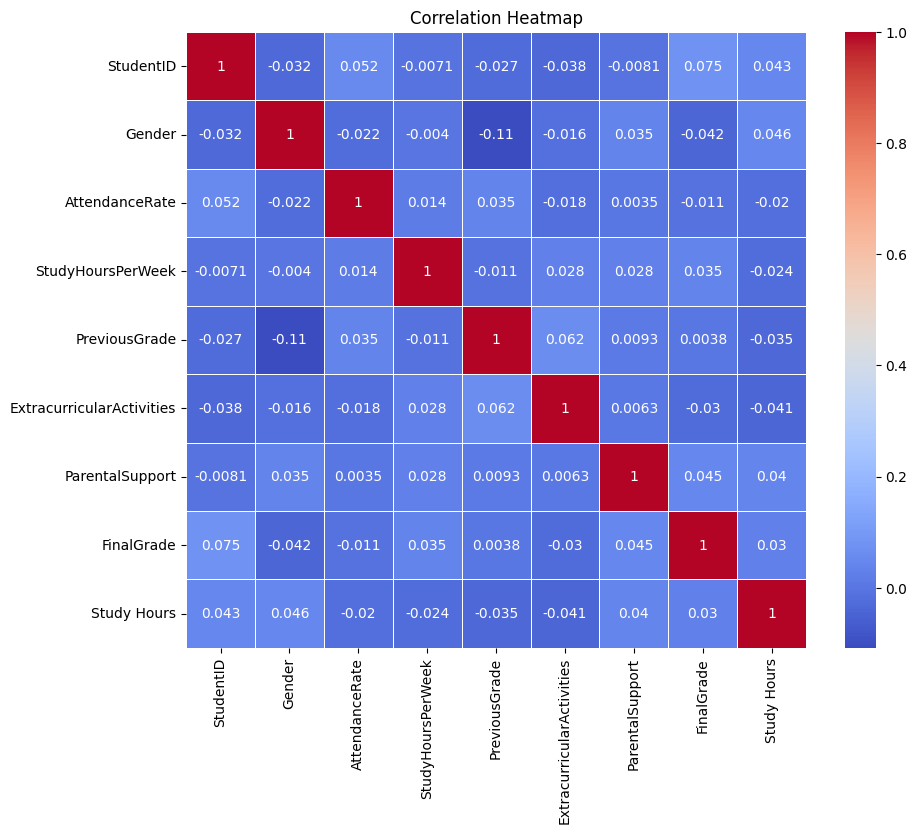

In [33]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

### Observation

Features with correlation values closer to **1** or **-1** have a stronger relationship with the target variable, while values closer to **0** indicate a weaker relationship.

## Step 12: Feature Engineering

Feature engineering involves creating new features from existing attributes to improve the quality of the dataset and potentially enhance model performance.

In [34]:
df["Improvement"] = df["FinalGrade"] - df["PreviousGrade"]

df.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Improvement
0,1.0,John,1,85.0,15.0,78.0,1,0,80.0,4.8,2.0
1,2.0,Sarah,0,90.0,20.0,85.0,2,2,87.0,2.2,2.0
2,3.0,Alex,1,78.0,10.0,65.0,0,1,68.0,4.6,3.0
3,4.0,Michael,1,92.0,25.0,90.0,3,0,92.0,2.9,2.0
4,5.0,Emma,0,88.0,18.0,82.0,2,2,85.0,4.1,3.0


### Observation

A new feature named **Improvement** was created by subtracting the previous grade from the final grade. This feature represents the academic progress of each student.

## Step 13: Data Type Conversion

Data type conversion ensures that each attribute has an appropriate data type for analysis and machine learning. In this dataset, the **StudentID** column is converted from an integer to a string since it represents an identifier rather than a numerical value.

In [35]:
print("Before Conversion")
print(df.dtypes)

Before Conversion
StudentID                    float64
Name                          object
Gender                         int64
AttendanceRate               float64
StudyHoursPerWeek            float64
PreviousGrade                float64
ExtracurricularActivities      int64
ParentalSupport                int64
FinalGrade                   float64
Study Hours                  float64
Improvement                  float64
dtype: object


In [36]:
df["StudentID"] = df["StudentID"].astype(str)

In [37]:
print("After Conversion")
print(df.dtypes)

After Conversion
StudentID                     object
Name                          object
Gender                         int64
AttendanceRate               float64
StudyHoursPerWeek            float64
PreviousGrade                float64
ExtracurricularActivities      int64
ParentalSupport                int64
FinalGrade                   float64
Study Hours                  float64
Improvement                  float64
dtype: object


## Step 14: Handle Inconsistent and Noisy Data

Data cleaning is performed to remove inconsistencies such as leading/trailing spaces and inconsistent letter casing in categorical columns. This ensures uniformity and improves data quality before analysis.

In [39]:
print("Categorical columns were standardized before Label Encoding.")
print("No further cleaning required.")

Categorical columns were standardized before Label Encoding.
No further cleaning required.


## Step 15: Split the Dataset into Training and Testing Sets

The dataset is divided into training and testing sets using Scikit-learn. The training set is used to train machine learning models, while the testing set is used to evaluate model performance.

In [40]:
from sklearn.model_selection import train_test_split

X = df.drop("FinalGrade", axis=1)

y = df["FinalGrade"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (800, 10)
Testing Features : (200, 10)
Training Labels : (800,)
Testing Labels : (200,)


## Step 16: Data Balancing

Data balancing techniques such as Random Oversampling and SMOTE are used only for classification problems. Since the target variable (**FinalGrade**) is continuous, this dataset represents a regression problem. Therefore, data balancing is not applicable.

In [41]:
print("FinalGrade is a continuous numerical variable.")
print("This is a regression dataset.")
print("Hence, SMOTE / Random Oversampling is not applicable.")

FinalGrade is a continuous numerical variable.
This is a regression dataset.
Hence, SMOTE / Random Oversampling is not applicable.


## Step 17: Visualize Data Distribution

The distribution of numerical features is visualized before and after preprocessing. This helps in understanding the effect of feature scaling on the dataset.

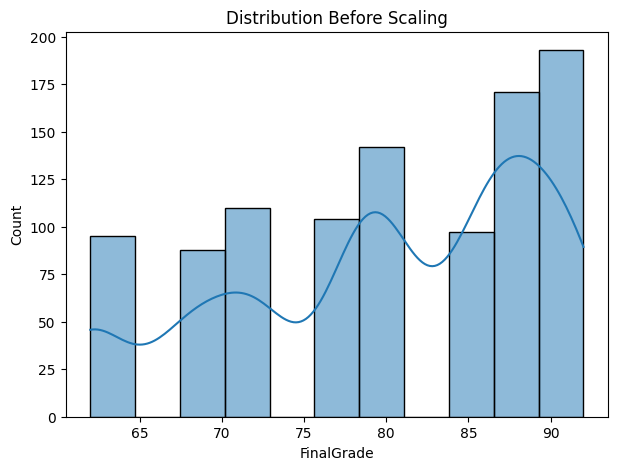

In [42]:
plt.figure(figsize=(7,5))

sns.histplot(df["FinalGrade"], kde=True)

plt.title("Distribution Before Scaling")

plt.show()

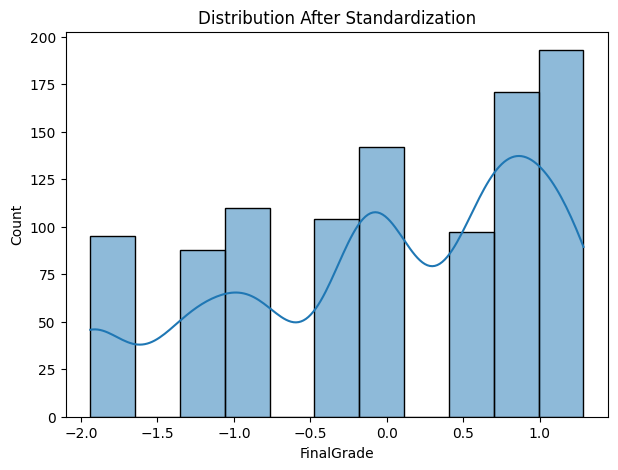

In [43]:
plt.figure(figsize=(7,5))

sns.histplot(df_standard["FinalGrade"], kde=True)

plt.title("Distribution After Standardization")

plt.show()

## Step 18: Compare the Dataset Before and After Preprocessing

The dataset is compared before and after preprocessing to observe the changes made during data cleaning. These changes include handling missing values, removing duplicates, encoding categorical variables, scaling numerical features, feature engineering, and preparing the dataset for machine learning.

In [44]:
print("Final Dataset Shape:", df.shape)

print("\nFirst Five Rows of the Preprocessed Dataset")
display(df.head())

print("\nMissing Values After Preprocessing")
print(df.isnull().sum())

print("\nData Types")
print(df.dtypes)

Final Dataset Shape: (1000, 11)

First Five Rows of the Preprocessed Dataset


,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Improvement
0,1.0,John,1,85.0,15.0,78.0,1,0,80.0,4.8,2.0
1,2.0,Sarah,0,90.0,20.0,85.0,2,2,87.0,2.2,2.0
2,3.0,Alex,1,78.0,10.0,65.0,0,1,68.0,4.6,3.0
3,4.0,Michael,1,92.0,25.0,90.0,3,0,92.0,2.9,2.0
4,5.0,Emma,0,88.0,18.0,82.0,2,2,85.0,4.1,3.0



Missing Values After Preprocessing
StudentID                    0
Name                         0
Gender                       0
AttendanceRate               0
StudyHoursPerWeek            0
PreviousGrade                0
ExtracurricularActivities    0
ParentalSupport              0
FinalGrade                   0
Study Hours                  0
Improvement                  0
dtype: int64

Data Types
StudentID                     object
Name                          object
Gender                         int64
AttendanceRate               float64
StudyHoursPerWeek            float64
PreviousGrade                float64
ExtracurricularActivities      int64
ParentalSupport                int64
FinalGrade                   float64
Study Hours                  float64
Improvement                  float64
dtype: object


### Summary of Changes

- Missing values were handled using median and mode.
- Duplicate records were removed.
- No outliers were found in the **FinalGrade** column.
- Categorical variables were converted into numerical form using Label Encoding and One-Hot Encoding.
- Numerical features were scaled using Min-Max Normalization and Standardization.
- A new feature named **Improvement** was created through feature engineering.
- The dataset was split into training and testing sets for machine learning.

## Step 19: Save the Preprocessed Dataset

The cleaned and preprocessed dataset is saved as a new CSV file. This file can be used for future analysis and machine learning tasks.

In [46]:
df.to_csv("cleaned_student_performance.csv", index=False)

print("Preprocessed dataset saved successfully.")

Preprocessed dataset saved successfully.


# Conclusion

The Student Performance dataset was successfully preprocessed using Python in Google Colab.

The following preprocessing tasks were completed:

- Loaded the dataset using Pandas.
- Examined the dataset structure.
- Performed exploratory data inspection.
- Detected and handled missing values.
- Removed duplicate records.
- Detected outliers using the IQR method.
- Verified that no outliers were present in the FinalGrade column.
- Converted categorical variables using Label Encoding and One-Hot Encoding.
- Applied Min-Max Normalization and Standardization.
- Performed feature selection using correlation analysis.
- Generated a correlation matrix and heatmap.
- Created a new feature (**Improvement**) through feature engineering.
- Converted data types where necessary.
- Handled inconsistent data.
- Split the dataset into training and testing sets.
- Determined that data balancing (SMOTE) was not applicable because the dataset is a regression dataset.
- Visualized the distribution of numerical features before and after preprocessing.
- Compared the dataset before and after preprocessing.
- Saved the cleaned dataset as a new CSV file.

The dataset is now clean, consistent, and ready for machine learning applications.